In [1]:
import seaborn as sns

sns.set_context('paper',font_scale=1.5)
sns.set_style('ticks')

# Formation energies

Formation energy plots are central in the analysis of point defects. The convention is to plot the formation energies as a function of the Fermi level, showing only the charge state with lowest formation energy. You can generate the plot automatically using the `DefectsAnalysis`. First we initialize the class following the previous examples: 

In [2]:
import pandas as pd
from defermi import DefectsAnalysis

bulk_volume = 800 # cubic Amstrong
data = [
{'name': 'Vac_O','charge': 2,'multiplicity': 1,'energy_diff': 7,'bulk_volume': bulk_volume},
{'name': 'Vac_O','charge':0,'multiplicity':1,'energy_diff': 10.8, 'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': -2,'multiplicity': 1,'energy_diff': 8,'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': 0,'multiplicity': 1,'energy_diff': 7.8,'bulk_volume': bulk_volume},
]
df = pd.DataFrame(data)
da = DefectsAnalysis.from_dataframe(df,band_gap=2.0,vbm=0.0)
da

,name,delta atoms,charge,multiplicity,corrections
0,Vac_O,{'O': -1},0,1,{}
1,Vac_O,{'O': -1},2,1,{}
2,Vac_Sr,{'Sr': -1},-2,1,{}
3,Vac_Sr,{'Sr': -1},0,1,{}


For the calculation of formation energies we need to define chemical potentials for each element, following:

$$ \Delta E_f = E_D - E_B + q(E_{VBM} + \epsilon_F) - \sum_i \Delta n_i \; \mu_i + E_{corr} $$

where:
- $E_D$ is the energy of the defective cell
- $E_B$ is the energy of the pristine cell
- $q$ is the charge
- $E_{VBM}$ is the valence band maximum
- $\epsilon_F$ is the Fermi level
- $\Delta n_i$ is the particle number difference btw defective and pristine cell
- $\mu_i$ is the chemical potential of particle $i$
- $E_{corr}$ are finite-size correction terms.

Chemical potentials can be defined using a dictionary, with element symbols as keys and chemical potentials as values. The formation energies are plotted using the `plot_formation_energy` method.

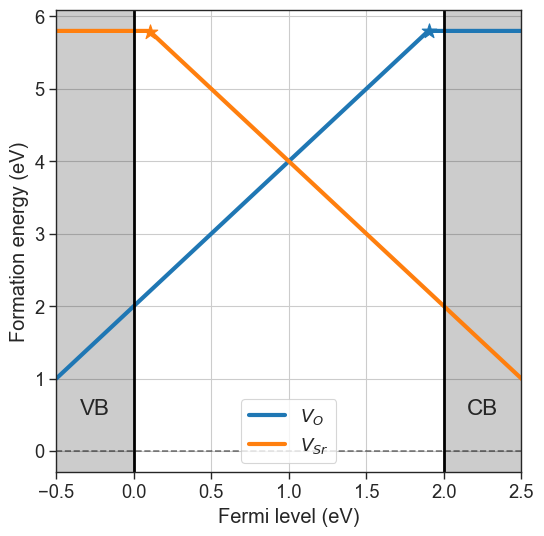

In [3]:
chempots = {'O':-5,'Sr':-2}

da.plot_formation_energies(chempots);

If chemical potentials are unknown, they can be pulled from the [Materials Project] (https://next-gen.materialsproject.org/). Different approaches for the choice of reservoir (set of chemical potentials) are available, which are accessed though the `chemical_potentials` argument in the `plot_formation_energies` function:
- **Elemental**: The chemical potentials are taken from the elemental phases for each elements (e.g. from $\mathrm{O_2}$ for oxygen). This is usually only for preliminary analysis and does not reflect experimental conditions properly. To use this option set `chemical_potentials="elemental"`.
- **Target phase + condition**: The reservoir choice is based on a reference phase and choosing a condition for a certain element (e.g. rich or poor). The phase diagram for the target composition is pulled from the database and the chemical potentials are selected either at the boundaries of stability for that phase, or the average between boundaries (`"middle"`). The input is a `tuple` with the composition of the target phase (`str`) and the condition `{element}-rich/poor/middle`, for example `chemical_potentials=("SrO","O-rich")`.
- **Target phase**: Chemical potentials are pulled for the target phase in all the previously mentioned conditions, and a figure with 3 formation energies plots is produced. If oxygen is present, it is chosen as the target element (e.g. `chemical_potentials="SrO"`).

Retrieving ThermoDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving ThermoDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

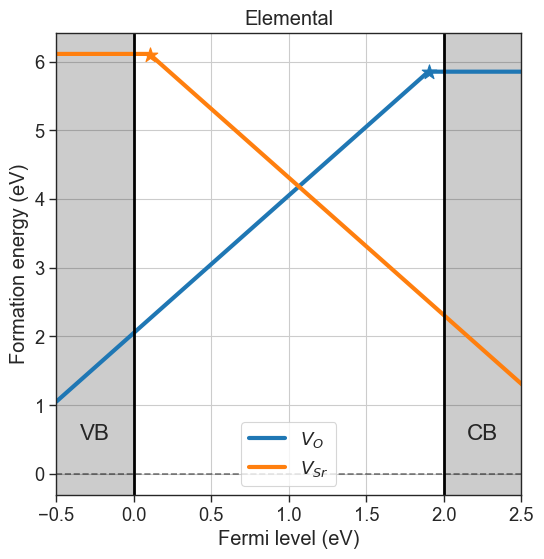

In [8]:
# Elemental chempots
da.plot_formation_energies(chemical_potentials='elemental',title='Elemental');

Pulling chemical potentials from Materials Project database...
Chemical potentials for composition = SrO and condition = O-middle:
{'Sr': -4.535489126666666, 'O': -8.256147023333332}


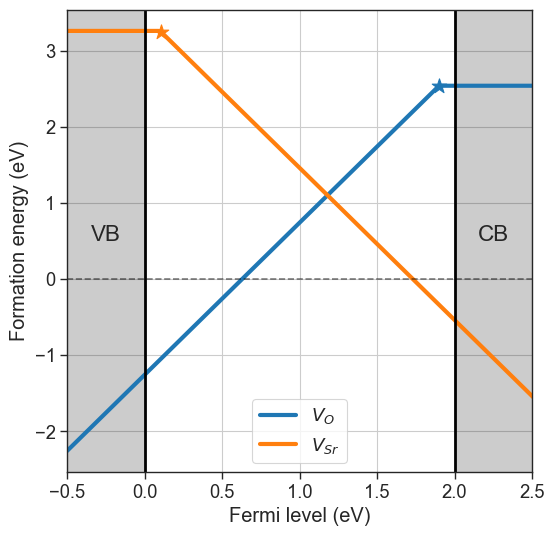

In [10]:
# Target phase + condition
da.plot_formation_energies(chemical_potentials=('SrO','O-middle'));

Pulling chemical potentials from Materials Project database...
Chemical potentials:
                 Sr          O
O-poor   -1.689493 -11.102143
O-middle -4.535489  -8.256147
O-rich   -7.381485  -5.410151


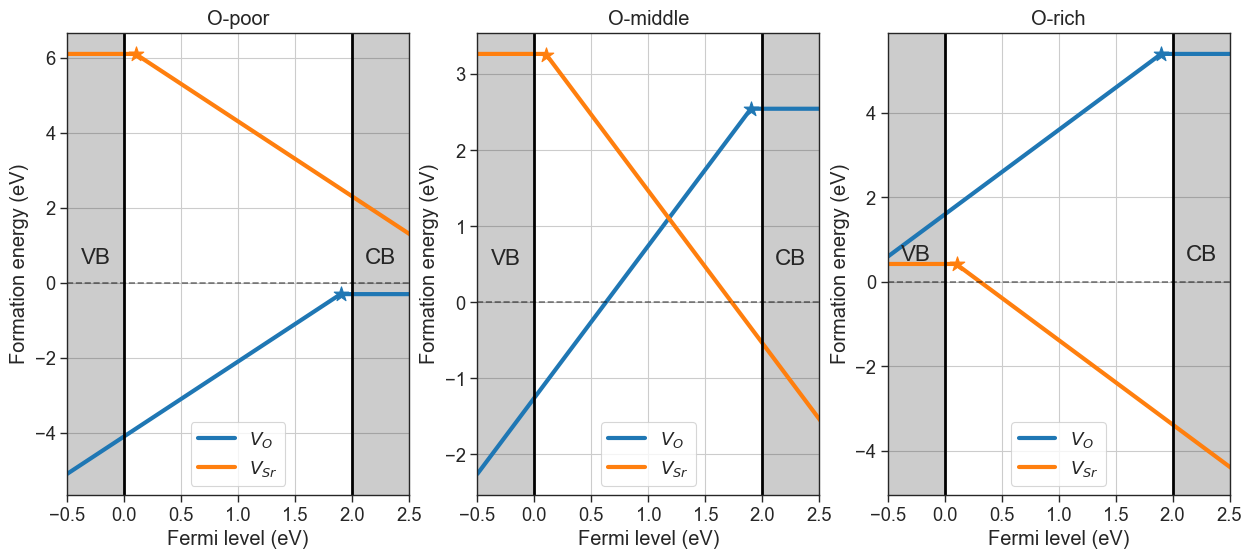

In [12]:
# Target phase + condition
da.plot_formation_energies(chemical_potentials='SrO',figsize=(15,6));

The generated chemical potentials are stored in the `chempots` attribute and function as nested dictionaries.

In [13]:
da.chempots

,Sr,O
O-poor,-1.689493,-11.102143
O-middle,-4.535489,-8.256147
O-rich,-7.381485,-5.410151
